In [1]:
!pip install numpy matplotlib

In [2]:
!pip install graphviz

In [3]:
!pip install torch

In [4]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
def f(x):
    return 3*x**2 -4*x + 5

In [6]:
f(3)

20

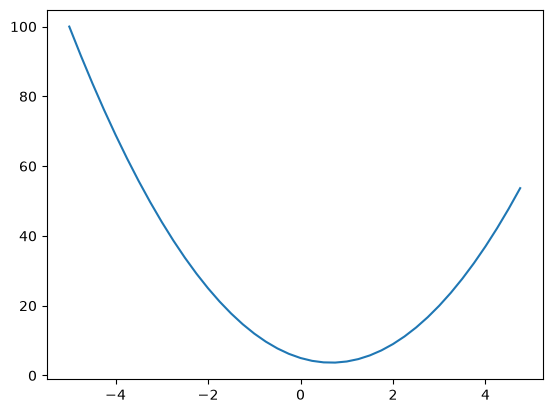

In [7]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

це демонстрація того, як працює пошук похідної. сама по собі похідна показує наскільки змінився f у перерахунку на одиницю зміни x. Тобто це нахил графіка в точці x: скільки одиниць f припадає на одиницю зміни x.

In [8]:
h=0.001
x=2/3
(f(x+h) - f(x))/h

0.0029999999995311555

In [9]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [10]:
h=0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
a+=h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


Value — це число, яке пам'ятає, з яких чисел і якою операцією його отримали. Завдяки цьому вирази автоматично будують граф обчислень, а backprop проходить цим графом назад і за правилом ланцюжка рахує grad (частинну похідну фінального виходу) для кожного вузла.

За допомогою _children ми можем отримати і подивитися на результати входів на цьому кроці, які були задіяні у виразі, а за допомогою _op можемо дізнатися останню операцію. При цьому _children i _op памʼятають тільки результати і операції на своєму рівні, вони не бачать, які операції були зроблені з входами раніше. Щоб це дізнатися, треба рекурсивно пройти по кожному з входів. Так ми обходимо граф обчислень, який уже був побудований під час самих операцій.

In [11]:
class Value:
    def __init__ (self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__ (self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
    
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
      
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self,), f'**{other}')
        
        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
            
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __radd__(self, other): # other + self
        return self + other
    
    def tanh (self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
            
        out._backward = _backward
        return out
            
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

Наразі я опрацював основні концепції градієнтів і бекпропагейшна. Далі розгляну базову побудову Нейрона (Neuron), Шару (Layer) і Багатошарового Перцептрона (MLP).

Важливо розрізняти два моменти: **створення** об'єкта (`__init__`) і його **виклик** з даними (`__call__`). Ваги створюються один раз при створенні і живуть між прикладами, а x щоразу приходять нові.

#### Neuron
Клас, який при створенні приймає кількість входів (nin) і рандомно створює стільки ж ваг, а також генерує байас. При виклику нейрон отримує дані (x), і нам треба перемножити усі пари x і w і добутки просумувати. Для цього в пайтоні використовується zip, який складає пари з двох послідовностей: (x1, w1), (x2, w2), ... Цю операцію ми робимо в циклі `sum(wi*xi for wi, xi in zip(self.w, x)) + self.b` і потім результат активуємо через тангенс наприклад або іншу функцію активації.

Тангенс тут прописаний в самому класі лише для спрощення туторіалу. В оригінальному micrograd є параметр `nonlin`, а в PyTorch активацію взагалі виносять окремим шаром (`nn.Tanh()`).

Ваги належать нейрону, бо це його параметри, які налаштовуються навчанням. На ілюстраціях стрілки — це входи x, а w на стрілці показує силу цього з'єднання. Де саме зберігати ваги — це деталь реалізації: PyTorch тримає ваги всіх нейронів шару як одну матрицю в шарі (`nn.Linear.weight`), а micrograd — окремо в кожному нейроні, бо так наочніше.

#### Layer
Клас, який на вхід приймає кількість входів (nin) для кожного нейрона і кількість нейронів (nout), яка дорівнює кількості виходів шару. При виклику шар подає ті самі x на кожен нейрон і повертає список їхніх виходів. Нейрони в шарі між собою незалежні, але кожен нейрон повністю законекчений з кожним входом (x).

#### MLP
Клас, який на вхід приймає розмір входу (кількість чисел у x) і список розмірів шарів, наприклад `MLP(3, [4, 4, 1])`. Кількість елементів у списку — це кількість шарів, кожне число — скільки в шарі нейронів, а останнє число — розмір виходу. Тут відбувається ітерація по шарам: вихід одного шару стає входом наступного.

In [12]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)] # список обʼєктів класу Neoruon 
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts # обʼєднуʼмо параметри в один список
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [13]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.07334291854048941)

In [14]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

Внизу я вручну порахував градієнт для кожного вузла виразу, використовуючи правило ланцюжка. Градієнт вузла — це  швидкість зміни фінального виходу L при зміні цього вузла. Наприклад, якщо b.grad = −4, то при зсуві b на 0.001 значення L зміниться приблизно на −4 · 0.001 = −0.004, тобто зменшиться. 

Градієнт вузла дорівнює локальній похідній, помноженій на градієнт результату операції, в яку цей вузол входить.  Локальна похідна — це похідна цієї операції по вузлу (для + це 1, для * — значення іншого входу). Якщо вузол входить у кілька операцій, внески від кожної додаються. 

У нейронній мережі функція активації (наприклад tanh), яку застосовують до зваженої суми кожного нейрона, — це просто ще одна операція в графі. Вона має свою локальну похідну, і backprop проходить через неї так само.

In [15]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label='e'
d = e + c; d.label='d'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

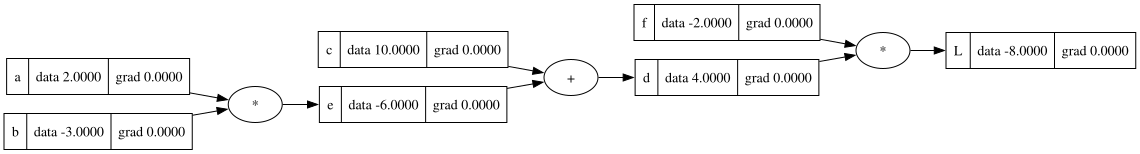

In [16]:
draw_dot(L)

In [17]:
b.grad = a.data * e.grad
a.grad = b.data * e.grad

In [18]:
e.grad = -2.0
c.grad = -2.0

In [19]:
f.grad = 4.0
d.grad = -2.0

In [20]:
L.grad = 1.0

Перевірив чисельно через зсув на h». Перевірив лише b, решту теж можна перевірити, перенісши += h на інший вузол

In [21]:
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

-3.9999999999995595


У цьому прикладі той самий backprop застосовано до нейрона: o = tanh(x1·w1 + x2·w2 + b). Правила + і * ті самі, але з'явилась нова операція tanh з локальною похідною 1 − tanh(n)² = 1 − o². Через неї grad проходить від o до n (1 − 0.7071² = 0.5), а далі + передає 0.5 без змін до b і до добутків x·w. 

w2.grad = 0, бо x2 = 0: якщо вхід нульовий, його вага не впливає на вихід, тож градієнтний спуск її не змінить. w1.grad = 1: збільшення w1 збільшує вихід нейрона.

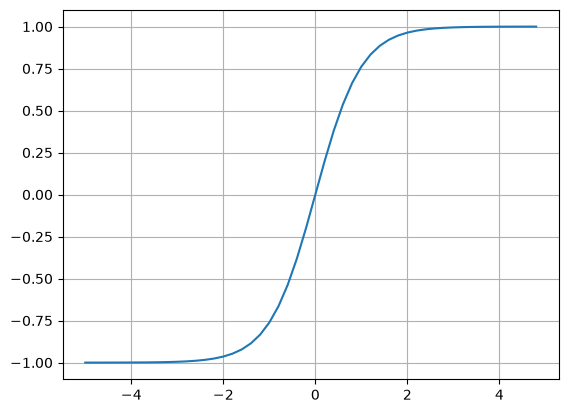

In [22]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [23]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weigts w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
bias = Value(6.8813735870195432, label="b")
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'
v = x1w1x2w2 + bias; n.label='n'
o = v.tanh(); o.label='o'

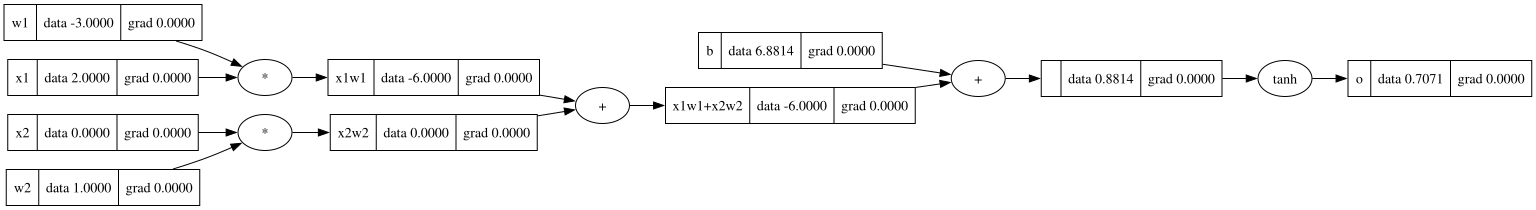

In [24]:
draw_dot(o)

In [25]:
w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad

In [26]:
w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad

In [27]:
x1w1.grad=0.5
x2w2.grad=0.5

In [28]:
bias.grad=0.5
x1w1x2w2.grad=0.5

In [29]:
n.grad= 1 - o.data**2

In [30]:
o.grad=1.0

Тут я застосував метод backward(), який робить backprop автоматично. Спершу він топологічно сортує граф: кожен вузол стоїть після всіх своїх дітей. Потім ставить grad = 1.0 для фінального вузла й іде по графу у зворотному порядку, викликаючи _backward() кожного вузла. Завдяки такому порядку grad вузла рахується лише тоді, коли всі його батьки (вузли, в які він входить) вже передали свої внески; внески додаються через +=.

Додатково я розбив tanh на серію простіших операцій (exp, +, −, /) і отримав ті самі градієнти. Отже, вузлом може бути операція будь-якого розміру — складна чи розбита на найменші частини. Головна умова: для кожної операції має бути відома її локальна похідна (як вихід залежить від кожного входу), щоб реалізувати _backward. Chain rule потім сам поєднує ці локальні похідні, тому результат не залежить від того, наскільки дрібно розбито вираз.

In [31]:
# inputs m1, m2
m1 = Value(2.0, label='m1')
m2 = Value(0.0, label='m2')
# weigts wt1, wt2
wt1 = Value(-3.0, label='wt1')
wt2 = Value(1.0, label='wt2')
# bias of neuron
bias2 = Value(6.8813735870195432, label="b2")
m1wt1 = m1*wt1; m1wt1.label='m1wt1'
m2wt2 = m2*wt2; m2wt2.label='m2wt2'
m1wt1m2wt2 = m1wt1 + m2wt2; m1wt1m2wt2.label='m1wt1+m2wt2'
k = m1wt1m2wt2 + bias2; k.label='k'
# ----
p = (2*k).exp()
s = (p - 1) / (p + 1)
# ----
s.label = 's'

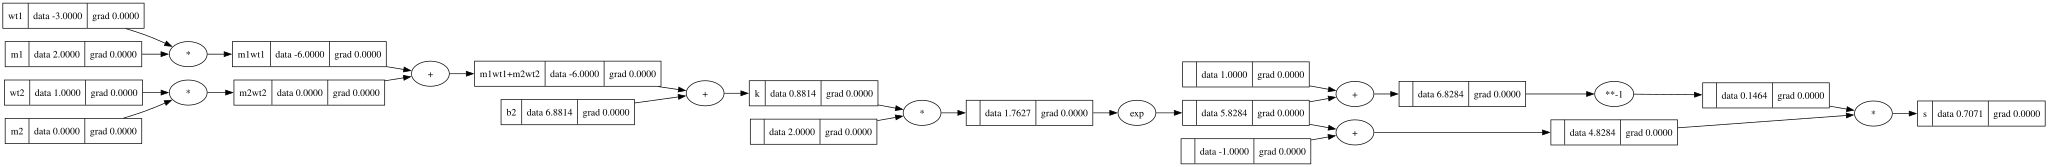

In [32]:
draw_dot(s)

In [33]:
s.backward()

Далі я реалізую той самий backprop за допомогою PyTorch. PyTorch оперує тензорами — багатовимірними масивами чисел, — що дає ефективні паралельні обчислення, зокрема на GPU.

В основі PyTorch ті самі ідеї, що я реалізував у класі Value (граф обчислень, локальні похідні, backward()), але розраховані на масштаб. Наприклад, requires_grad для звичайних тензорів за замовчуванням False: градієнти потрібні лише параметрам, які ми навчаємо (вагам і bias), а не вхідним даним x. Шари на кшталт nn.Linear створюють свої ваги вже з requires_grad=True. У реальних моделях мільйони чисел, і будувати граф обчислень для всього підряд коштувало б дуже багато пам'яті й часу. Під час інференсу відстеження вимикають повністю (torch.no_grad()): модель лише передбачає, backprop не запускається, тож граф не потрібен.

Тип приводжу до float64 (.double()), щоб результати точно збігались із micrograd, бо Python float — це float64, а PyTorch за замовчуванням використовує float32. У реальному навчанні часто йдуть у протилежний бік — float16/bfloat16: точність майже не страждає, а пам'яті потрібно вдвічі менше, і обчислення значно швидші.

In [34]:
import torch

In [35]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
v = x1*w1 + x2*w2 + b
o = torch.tanh(v)

o.backward()
print(o.data.item())

print('---')
print(w2.grad.item())
print(x2.grad.item())
print(w1.grad.item())
print(x1.grad.item())


0.7071066904050358
---
0.0
0.5000001283844369
1.0000002567688737
-1.5000003851533106


Вище я створив три класи: нейрон, шар, млп. Далі ми сетапимо MLP і подаємо йому на вхід наші дані. Сетапимо лос функцію, яка буде рахувати наскільки наша модель гарно або погано передбачає лейбли. Далі визначаємо льорнінг рейт — наскільки значення ваг будуть сунутись на кожному кроці — і кількість кроків навчання. Напрямок зміни залежить від знаку градієнта для конкретного параметра (ваги чи байаса): якщо -, тоді треба збільшувати, якщо +, то зменшувати, оскільки знак градієнта показує, чи зросте лос, якщо збільшити цей параметр, а нам треба йти в протилежну сторону для зменшення лоса. Величина кроку залежить не лише від знаку, а й від розміру градієнта: `p.data -= lr * p.grad`.

Один крок навчання:
1. forward — прогнати дані через MLP;
2. порахувати лос;
3. обнулити градієнти;
4. `loss.backward()`;
5. оновити параметри.

Також важливо не забувати обнуляти градієнт перед кожною ітерацією, оскільки, як ми памʼятаєм, градієнти сумуються, відповідно це дуже часта, але сліпа помилка, бо навчання не впаде.

In [36]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # таргет

In [ ]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  # нижче — це те саме, що я робив напочатку з L, тільки граф набагато більший
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # SSE — Sum Squared Error
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)

0 0.025066377617564525
1 0.023629518409528504
2 0.022342621712536908
3 0.021183683633987996
4 0.020134779013322023
5 0.019181160291801898
6 0.018310585243695415
7 0.017512808360160212
8 0.016779191164437574
9 0.016102400216590877
10 0.015476170622286522
11 0.014895119057667185
12 0.01435459463391587
13 0.013850558969444255
14 0.01337948901642405
15 0.012938297767126163
16 0.012524269122602438
17 0.01213500406327141
18 0.011768375902018428
19 0.011422492884331267


In [40]:
ypred

[Value(data=0.9495036705265035),
 Value(data=-0.973356754862323),
 Value(data=-0.9294437106057475),
 Value(data=0.9435680843007833)]